# scRITMO: Phase Inference on Unsynchronized Cells

This notebook downloads and analyzes the FLASH-seq 3T3 dataset from our paper
directly from GEO ([**GSE325045**](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE325045)),
then runs scRITMO on it with (mostly) default settings.

Unlike [`tutorial_inference.ipynb`](tutorial_inference.ipynb), these cells have **no external
time label**: the NIH3T3 fibroblasts are cycling freely and asynchronously in culture, so there is
no ZT to compare against. The inferred phase for each cell comes purely from its own transcriptome —
this is exactly the "hard" regime the method is built for.

---
**Pipeline overview:**
1. Download the raw count matrix from GEO
2. Load it into an AnnData object
3. Load the reference circadian gene parameters
4. Map gene symbols to the Ensembl gene IDs used in this dataset
5. Run inference


In [1]:
import os
import json
import urllib.request
import urllib.parse

import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import matplotlib.pyplot as plt

import scritmo as sr
import scritmo.ml as cr

%load_ext autoreload
%autoreload 2


Duplicate key in file PosixPath('/home/maxine/miniconda3/envs/torch/lib/python3.12/site-packages/matplotlib/mpl-data/matplotlibrc'), line 368 ('axes.facecolor:     white   # axes background color')
Duplicate key in file PosixPath('/home/maxine/miniconda3/envs/torch/lib/python3.12/site-packages/matplotlib/mpl-data/matplotlibrc'), line 569 ('figure.facecolor:   white     # figure face color')


## 1. Download the data

The FLASH-seq data are available on GEO under accession
[GSE325045](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE325045). We pull the processed,
per-cell raw count matrix straight from the GEO FTP mirror and cache it locally so re-running this
notebook doesn't re-download it.


In [2]:
DATA_DIR = "data/GSE325045"
os.makedirs(DATA_DIR, exist_ok=True)

GEO_BASE = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE325nnn/GSE325045/suppl/"
COUNTS_FILE = "GSE325045_Raw_counts_all_samples.csv.gz"
counts_path = os.path.join(DATA_DIR, COUNTS_FILE)

if not os.path.exists(counts_path):
    print(f"Downloading {COUNTS_FILE} from GEO (GSE325045)...")
    urllib.request.urlretrieve(GEO_BASE + COUNTS_FILE, counts_path)
    print("Done.")
else:
    print("Using cached file:", counts_path)


Using cached file: data/GSE325045/GSE325045_Raw_counts_all_samples.csv.gz


## 2. Load into an AnnData object

The GEO file is a genes (rows) × cells (columns) count matrix, one column per FLASH-seq well. We
transpose it to the usual cells × genes orientation and store the counts as `layers["spliced"]`,
which is what `scritmo` expects by default.


In [3]:
counts_df = pd.read_csv(counts_path, index_col=0).T  # -> cells x genes

adata = ad.AnnData(
    X=sp.csr_matrix(counts_df.values.astype(np.float32)),
    obs=pd.DataFrame(index=counts_df.index),
    var=pd.DataFrame(index=counts_df.columns),
)
adata.layers["spliced"] = adata.X.copy()

# GEO ships Ensembl IDs with a version suffix (e.g. ENSMUSG00000020889.9); drop it
adata.var_names = [g.split(".")[0] for g in adata.var_names]
adata.var_names_make_unique()

adata


AnnData object with n_obs × n_vars = 768 × 33757
    layers: 'spliced'

## 3. Reference gene parameters

Same Zhang reference circadian gene set (`ccg_zhang_context.csv`) used in
[`tutorial_inference.ipynb`](tutorial_inference.ipynb), loaded via `cr.get_ccg_pars()`.


In [4]:
params_g = cr.get_ccg_pars()
params_g


,a_0,a_1,b_1,phase,amp,log2fc,log10_mean,disp
Bhlhe40,-10.039983,-0.168747,0.041074,2.902832,0.173673,0.501115,-4.360309,0.071415
Bhlhe41,-9.289599,-0.427272,0.358016,2.444159,0.557438,1.608426,-4.034422,0.071415
Bmal1,-12.275592,1.372668,-0.523622,5.918761,1.469148,4.239066,-5.331222,0.071415
Ciart,-10.237618,-1.192793,0.346538,2.858849,1.242113,3.583980,-4.446141,0.071415
Clock,-10.968863,0.320745,-0.065373,6.082123,0.327340,0.944502,-4.763716,0.071415
Cry1,-11.691333,-0.007351,-0.584934,4.699823,0.584980,1.687897,-5.077481,0.071415
Dbp,-8.881467,-1.285762,1.063675,2.450442,1.668709,4.814876,-3.857172,0.071415
Npas2,-14.378429,1.468749,-0.242097,6.119822,1.488568,4.295100,-6.244473,0.071415
Nr1d1,-8.387754,-0.457018,1.437220,1.878672,1.508133,4.351553,-3.642755,0.071415
Nr1d2,-10.921415,-0.587953,0.511821,2.425310,0.779518,2.249215,-4.743110,0.071415


## 4. Map gene symbols to Ensembl IDs

`params_g` is indexed by gene symbol (`Bmal1`, `Per2`, ...), but this dataset's count matrix is
indexed by Ensembl gene ID. We look up the mouse Ensembl ID for each reference gene via
[mygene.info](https://mygene.info) and rename the matching columns in `adata`.


In [5]:
def symbols_to_mouse_ensembl(symbols):
    """Look up mouse Ensembl gene IDs for a list of gene symbols via mygene.info."""
    data = urllib.parse.urlencode(
        {
            "q": ",".join(symbols),
            "scopes": "symbol",
            "species": "mouse",
            "fields": "ensembl.gene",
        }
    ).encode()
    req = urllib.request.Request("https://mygene.info/v3/query", data=data)
    with urllib.request.urlopen(req) as resp:
        hits = json.loads(resp.read())

    symbol_to_ensembl = {}
    for hit in hits:
        genes = hit.get("ensembl")
        if genes is None:
            continue
        if isinstance(genes, dict):
            genes = [genes]
        mouse_ids = [g["gene"] for g in genes if g["gene"].startswith("ENSMUSG")]
        if mouse_ids:
            symbol_to_ensembl[hit["query"]] = mouse_ids[0]
    return symbol_to_ensembl


symbol_to_ensembl = symbols_to_mouse_ensembl(params_g.index)
ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

adata.var_names = [ensembl_to_symbol.get(g, g) for g in adata.var_names]
adata.var_names_make_unique()

missing = [g for g in params_g.index if g not in adata.var_names]
assert not missing, f"Could not map these reference genes to the count matrix: {missing}"
print(f"Mapped all {len(params_g.index)} reference genes to Ensembl IDs in the count matrix.")


Mapped all 15 reference genes to Ensembl IDs in the count matrix.


## 5. Run inference

`adata` still carries the full transcriptome (not just the reference genes), so the per-cell
library size scritmo needs for the count model is computed automatically from it — no need to pass
`counts=` by hand.

We only override the arguments that matter for this dataset, the same regime used for the 3T3 fit
in the paper:
- `k_beta=2.0` — soft Von-Mises prior anchoring each gene's acrophase to the reference (the
  "production" regime; see `warmup_and_train`'s docstring for the alternatives)
- `n_theta=48` — a finer training phase-grid
- `n_theta_post=100` — a smoother posterior per cell, for nicer plots
- `n_epochs=600` — the default (300) doesn't fully converge on this dataset; 600 does

Everything else (`fix_phase=False`, `noise_model="nb"`, `layer="spliced"`, `init_mean=True`,
`kill_amps=False`, ...) is left at its default. There is no `true_phase` here: these
cells are unsynchronized, so there is nothing external to track error against — the posterior phase
is the end result, not a diagnostic.


In [6]:
cmodel, losses, mad_epochs = cr.warmup_and_train(
    adata,
    params_g,
    k_beta=2.0,
    n_theta=48,
    n_theta_post=100,
    batch_size=128,
    n_epochs=600,
)


Running in serial mode.


Fitting genes (serial): 100%|██████████| 15/15 [00:00<00:00, 321.30it/s]



training model...


Training Progress: 100%|██████████| 600/600 [00:12<00:00, 49.02it/s, epoch=600/600, loss=5.7943e+01]


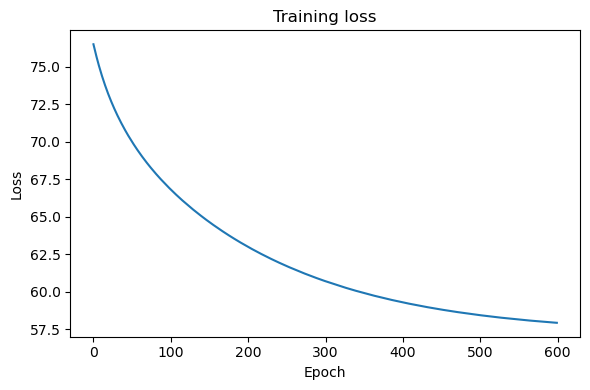

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()


### Gene-level amplitude and acrophase

`cmodel.get_parameter_dataframe()` returns the trained per-gene parameters as a `Beta` table
(amplitude, acrophase, log-mesor, dispersion, ...). Its `.plot_circular()` method puts each gene on
a polar plot: angle is the acrophase (peak expression time), radius is the log2 fold-change
amplitude — the same view as Figure 1 of the paper for the reference gene set, but with the
amplitudes and phases re-fit to this dataset instead of taken from the reference.


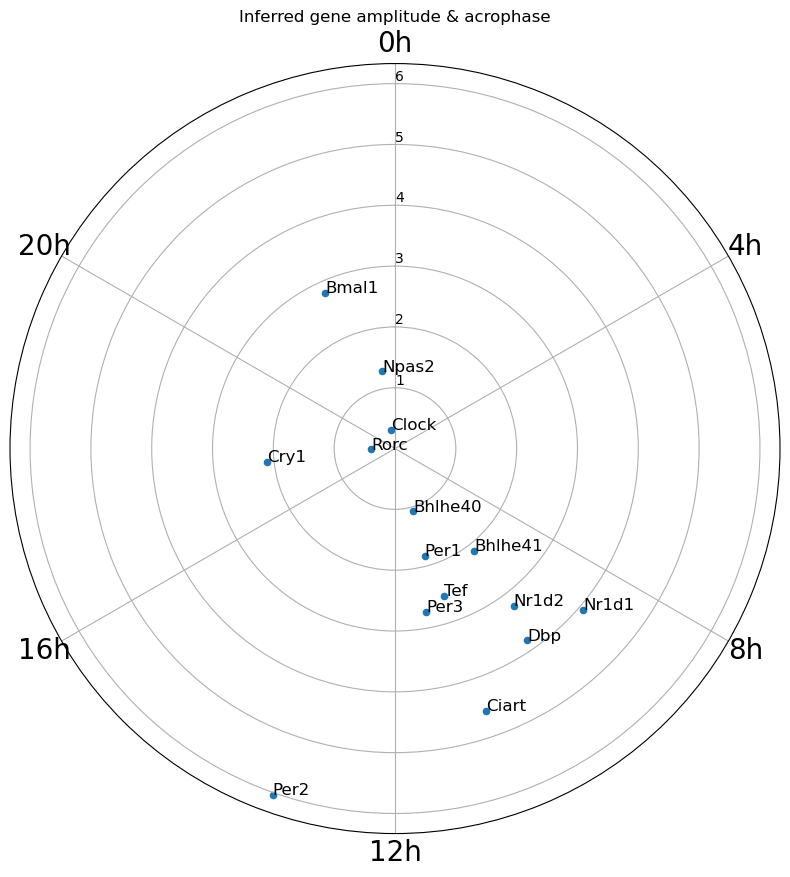

In [8]:
params_g_inf = cmodel.get_parameter_dataframe()

params_g_inf.plot_circular(title="Inferred gene amplitude & acrophase")
plt.show()


### Inferred phase distribution

With no ground-truth time to compare against, the population phase distribution itself is the
object of interest here — it directly reflects how spread out (desynchronized) these freely-cycling
cells are.

From here, the same biological desynchrony quantification shown in
[`tutorial_inference.ipynb`](tutorial_inference.ipynb) applies unchanged, via
`cmodel.estimate_phase_desynchrony(...)`.


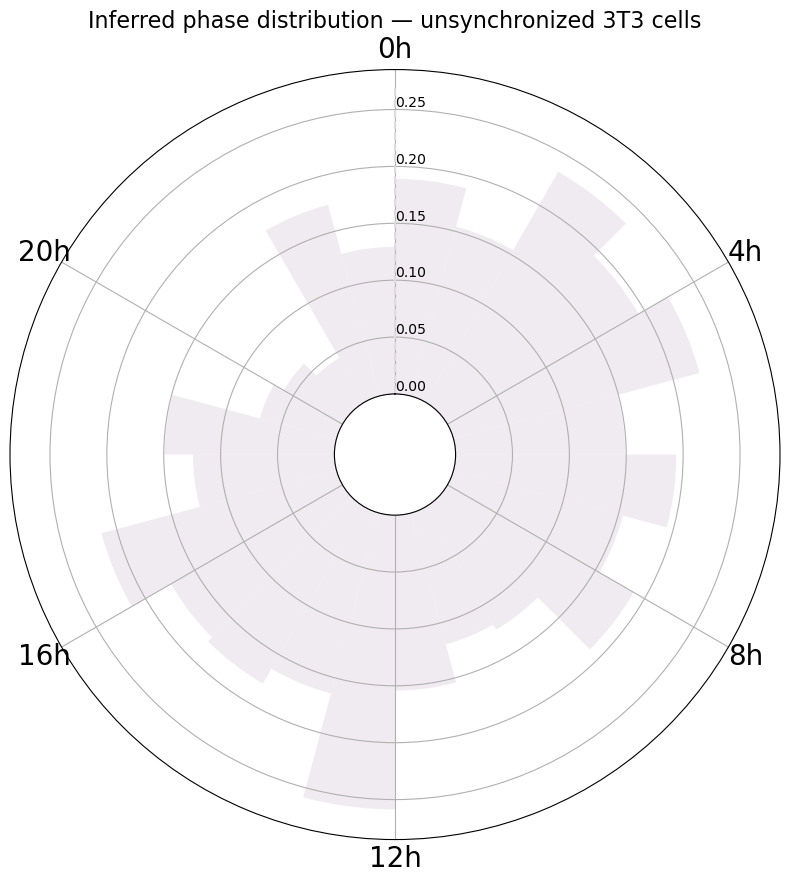

In [9]:
phi = cmodel.post_mode_c

fig, ax = sr.plot_phase_polar_population(
    phases=phi,
    time=np.zeros_like(phi),
    show_legend=False,
    bins=24,
    hist_density=True,
    inner_ring_size=0.2,
)
ax.set_title("Inferred phase distribution — unsynchronized 3T3 cells", fontsize=16)
plt.show()
